# Holiday Identification by Daily Profile Clustering

This notebook flags atypical days in one demand series by comparing each daily profile against its `(segment, weekday)` reference group.

It loads observed data, builds day-level profiles, measures distance to the group centroid, and compares detected outliers against the local holiday catalog.

This is exploratory notebook code, not part of the production pipeline.

In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import analog_holidays.shared.identify_holidays as identify_holidays_module
identify_holidays_module = importlib.reload(identify_holidays_module)

from analog_holidays.shared.dataset_config import ACTIVE_CONFIG, list_dataset_regions
from analog_holidays.shared.identify_holidays import (
    build_holiday_groups,
    build_holiday_selector_features,
    build_wide_df,
    compare_outliers_holidays,
    compute_distances,
    detect_outliers,
    display_cluster_holiday_crosstab,
    display_cluster_38h_crosstab,
    find_holidays_not_detected,
    get_date_sets,
    get_hour_cols,
    load_holidays_catalog,
    load_results_data,
    plot_distance_distribution,
    plot_profiles_by_holiday,
    plot_profiles_by_segment_dow,
    print_summary,
    report_nth_monday_holidays,
    run_analog_cluster_38h_analysis,
    run_cluster_ab_validation,
    run_cluster_38h_analysis,
    run_cluster_atypical_analysis,
    run_holiday_ab_validation,
 )

DEMAND_PATH = ACTIVE_CONFIG.demand_path
HOLIDAYS_PATH = ACTIVE_CONFIG.notebook_holidays_path

print(f'Active dataset: {ACTIVE_CONFIG.key}')
print(f'Demand CSV: {DEMAND_PATH}')
print(f'Holidays: {HOLIDAYS_PATH}')


Active dataset: mx
Demand CSV: C:\GIT\analog_holidays\holidays\holiday_demand_mx.csv
Holidays: C:\GIT\analog_holidays\holidays\holidays_recognized.json


## 1. Configuration

In [2]:
UNIQUE_ID = 'SEN_demand_NES'

DATE_END = '2025-01-01'
SELECTOR_FUTURE_END = '2026-12-31'
CLUSTERING_CRITERIUM = 'observance_tier'
CLUSTERING_CRITERIA_CATALOG = identify_holidays_module.ANALOG_CLUSTER_CRITERIA_CATALOG.copy()
# Public criterion catalog exposed by the selector pipeline:
# - 'shape_pearson_CDE_map_FGH' keeps the current 38h shape-based C/D/E -> F/G/H mapping.
# - 'seasonal_heat_cold' groups holiday dates into heat vs cold seasons, mapping Spring/Summer to heat and Autumn/Winter to cold.
# - 'seasonal_winter_sprint_fall' groups holiday dates by year season and maps Winter/Spring/Fall/Summer to stable analog labels.
# - 'best_matching_weekday' groups holiday dates by the closest weekday-profile label assigned to each date.
# - 'observance_tier' groups holiday dates by how inhábil they actually are (working/partial/full), derived from observed_strength.


AVAILABLE_UNIQUE_IDS = list_dataset_regions()
if not AVAILABLE_UNIQUE_IDS:
    raise ValueError(f'No configured series were found in {DEMAND_PATH}.')
if UNIQUE_ID is None:
    UNIQUE_ID = AVAILABLE_UNIQUE_IDS[0]
elif UNIQUE_ID not in AVAILABLE_UNIQUE_IDS:
    raise ValueError(
        f'Series {UNIQUE_ID!r} not found. Available: {AVAILABLE_UNIQUE_IDS}'
    )

MONTH_NAMES = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December',
]

SEGMENTS = [
    {'label': 'Spring', 'months': [3, 4, 5]},
    {'label': 'Summer', 'months': [6, 7, 8]},
    {'label': 'Autumn', 'months': [9, 10, 11]},
    {'label': 'Winter', 'months': [12, 1, 2]},
]

SEGMENTS = [{'label': month_name, 'months': [month_number]} for month_number, month_name in enumerate(MONTH_NAMES, start=1)]

OUTLIER_PERCENTILE = 95
EXCLUDE_KNOWN_HOLIDAYS_FROM_BASELINE = True
KNOWN_HOLIDAY_MIN_GROUP_PERCENTILE = 75
DISTANCE_METRIC = 'PEARSON'

N_CLUSTERS_PHOL    = 3   # clusters for 38-h eve+holiday profiles (section 8c-bis)
PREVIOUSLY_W_HOURS = 14  # hours taken from the eve day

WEEKDAY_NAMES = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

print(f'Series:   {UNIQUE_ID}')
print(f'DATE_END: {DATE_END}')
print(f'SELECTOR_FUTURE_END: {SELECTOR_FUTURE_END}')
print(f'CLUSTERING_CRITERIUM: {CLUSTERING_CRITERIUM}')
print(f'Criterion catalog: {tuple(CLUSTERING_CRITERIA_CATALOG)}')
print(f'Available series: {AVAILABLE_UNIQUE_IDS}')
display(
    pd.DataFrame(
        [
            {'criterion': criterion_name, 'description': criterion_description}
            for criterion_name, criterion_description in CLUSTERING_CRITERIA_CATALOG.items()
        ]
    )
)


Series:   SEN_demand_NES
DATE_END: 2025-01-01
SELECTOR_FUTURE_END: 2026-12-31
CLUSTERING_CRITERIUM: best_matching_weekday
Criterion catalog: ('shape_pearson_CDE_map_FGH', 'seasonal_heat_cold', 'seasonal_winter_sprint_fall', 'best_matching_weekday')
Available series: ['SEN_demand_SIN', 'SEN_demand_CEL', 'SEN_demand_OCC', 'SEN_demand_NOR', 'SEN_demand_PEN', 'SEN_demand_ORI', 'SEN_demand_NES', 'SEN_demand_NTE']


,criterion,description
0,shape_pearson_CDE_map_FGH,Maps the current 38h shape-based event_profile...
1,seasonal_heat_cold,Groups holiday dates into heat vs cold seasons...
2,seasonal_winter_sprint_fall,Groups holiday dates by year season and maps W...
3,best_matching_weekday,"Groups holiday dates by best_matching_weekday,..."


## 2. Load observed data from CSV

In [3]:
MONTH_TO_SEGMENT = {month: segment['label'] for segment in SEGMENTS for month in segment['months']}
SEGMENT_LABELS = [segment['label'] for segment in SEGMENTS]

df_raw = load_results_data(DEMAND_PATH, UNIQUE_ID)
if DATE_END is not None:
    cutoff_ts = pd.Timestamp(DATE_END)
    df_raw = df_raw[df_raw['ds'] < cutoff_ts].copy()
    if df_raw.empty:
        raise ValueError(f'No data available for {UNIQUE_ID} before {cutoff_ts.date()}.')

print(f'Series: {UNIQUE_ID}')
print(f'Records: {len(df_raw):,}')
if DATE_END is not None:
    print(f'DATE_END cutoff: {pd.Timestamp(DATE_END).date()} (exclusive)')
print(f'Range: {df_raw["ds"].min()} → {df_raw["ds"].max()}')
df_raw.head()

Series: SEN_demand_NES
Records: 35,016
DATE_END cutoff: 2025-01-01 (exclusive)
Range: 2020-01-02 00:00:00 → 2024-12-31 23:00:00


,ds,y
0,2020-01-02 00:00:00,3989.11732
1,2020-01-02 01:00:00,3811.13385
2,2020-01-02 02:00:00,3729.55369
3,2020-01-02 03:00:00,3704.02220
4,2020-01-02 04:00:00,3623.63396


## 3. Pivot to wide format (1 row = 1 day, 24 columns = hours)

In [4]:
df_wide = build_wide_df(df_raw, MONTH_TO_SEGMENT, exclude_years=[2022])
HOUR_COLS = get_hour_cols(df_wide)
year_min = int(df_wide.index.year.min())
year_max = int(df_wide.index.year.max())
df_holidays = load_holidays_catalog(HOLIDAYS_PATH, year_min, year_max)
df_holidays_display = df_holidays.copy()
KNOWN_HOLIDAY_DATES = (
    set(pd.to_datetime(df_holidays['date']).dt.normalize())
    if EXCLUDE_KNOWN_HOLIDAYS_FROM_BASELINE else set()
 )

print(f'Complete days: {len(df_wide)}')
print(f'Segments ({len(SEGMENT_LABELS)}):')
for segment_label in SEGMENT_LABELS:
    n_days = (df_wide['segment'] == segment_label).sum()
    print(f'  {segment_label}: {n_days} days')
print(f'Catalog holidays in range: {len(df_holidays)}')
print(f'Dates excluded from the baseline: {len(KNOWN_HOLIDAY_DATES)}')
df_wide.head()

Complete days: 1459
Segments (12):
  January: 123 days
  February: 114 days
  March: 124 days
  April: 118 days
  May: 124 days
  June: 120 days
  July: 124 days
  August: 124 days
  September: 120 days
  October: 124 days
  November: 120 days
  December: 124 days
Catalog holidays in range: 60
Dates excluded from the baseline: 60


hour,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,dow,month,segment
date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,3989.11732,3811.13385,3729.55369,3704.02220,3623.63396,3669.38772,3738.41664,4007.57093,4252.22391,4513.80029,...,5089.61978,5126.34880,5111.48442,5117.78624,5133.68408,5063.83517,4997.74371,3,1,January
2020-01-03,4998.18417,4785.98638,4563.18781,4550.29791,4480.86959,4479.75694,4505.15813,4591.89841,4803.65381,5051.95702,...,5157.07236,5077.20660,5135.69712,5216.07793,5123.12232,5065.50332,5070.96521,4,1,January
2020-01-04,5065.11958,4862.07545,4751.80962,4560.58457,4524.59933,4594.95663,4578.80988,4651.98461,4776.50702,4891.03260,...,4722.39715,4786.64318,5029.64567,4994.47847,4973.43021,4872.17004,4814.74244,5,1,January
2020-01-05,4701.26490,4518.11116,4412.77966,4301.03683,4271.97698,4174.64173,4166.71719,4168.12280,4053.60337,4100.16908,...,4298.99879,4326.57330,4656.41006,4920.41659,4924.71350,4769.33195,4600.61478,6,1,January
2020-01-06,4558.16435,4415.83487,4393.86265,4300.84801,4307.12042,4324.73204,4401.99545,4656.75796,5055.54916,5263.80573,...,5456.65101,5404.49611,5501.46532,5574.14980,5569.66786,5367.38557,5302.92665,0,1,January


## 4. Compute distances by segment and weekday

Distances are computed inside each `(segment, dow)` group against that group's reference centroid.

`DISTANCE_METRIC` controls whether the score emphasizes magnitude, shape, or both.

In [5]:
df_dist = compute_distances(
    df_wide,
    HOUR_COLS,
    SEGMENT_LABELS,
    WEEKDAY_NAMES,
    distance_metric=DISTANCE_METRIC,
    reference_exclude_dates=KNOWN_HOLIDAY_DATES,
 )

print(f'Distance metric: {DISTANCE_METRIC}')
if DISTANCE_METRIC == 'PEARSON_EUCLIDIAN':
    print('  Euclidean and Pearson components combined after group-wise normalization')
elif DISTANCE_METRIC == 'EUCLIDIAN':
    print('  Euclidean distance only')
elif DISTANCE_METRIC == 'PEARSON':
    print('  1 - Pearson r only')
print(f'\nSegments: {SEGMENT_LABELS}')
print(f'Total records (day × group): {len(df_dist)}')
df_dist.head(10)

Distance metric: PEARSON
  1 - Pearson r only

Segments: ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
Total records (day × group): 1459


,date,segment,dow,dow_name,dist_eucl,dist_pearson,dist_eucl_norm,dist_pearson_norm,is_reference_day,distance
0,2020-01-06,January,0,Monday,2533.998364,0.005338,0.791556,-0.474029,True,-0.474029
1,2020-01-13,January,0,Monday,1461.612455,0.008888,-0.156130,-0.369052,True,-0.369052
2,2020-01-20,January,0,Monday,1317.285451,0.027710,-0.283674,0.187498,True,0.187498
3,2020-01-27,January,0,Monday,1337.383871,0.008888,-0.265913,-0.369053,True,-0.369053
4,2021-01-04,January,0,Monday,1760.028741,0.006801,0.107586,-0.430772,True,-0.430772
5,2021-01-11,January,0,Monday,3345.063900,0.011725,1.508309,-0.285170,True,-0.285170
6,2021-01-18,January,0,Monday,925.294678,0.006879,-0.630083,-0.428447,True,-0.428447
7,2021-01-25,January,0,Monday,455.615026,0.013893,-1.045147,-0.221066,True,-0.221066
8,2023-01-02,January,0,Monday,3323.796659,0.029356,1.489514,0.236151,True,0.236151
9,2023-01-09,January,0,Monday,426.520374,0.008676,-1.070859,-0.375327,True,-0.375327


## 6. Load the local recognized holidays catalog (`holidays/holidays_recognized.json`)

In [6]:
df_dist, df_outliers = detect_outliers(
    df_dist,
    OUTLIER_PERCENTILE,
    threshold_reference_only=EXCLUDE_KNOWN_HOLIDAYS_FROM_BASELINE,
    promote_dates=KNOWN_HOLIDAY_DATES,
    promote_min_group_percentile=KNOWN_HOLIDAY_MIN_GROUP_PERCENTILE,
)

print(f'Detected outliers: {len(df_outliers)}')
print(f'Out of a total of {len(df_dist)} days')
print(f'Percentage: {100 * len(df_outliers) / len(df_dist):.1f}%')
print(f'Known holidays rescued by within-group percentile: {int(df_dist["is_promoted_outlier"].sum())}')
df_outliers.head(20)

Detected outliers: 127
Out of a total of 1459 days
Percentage: 8.7%
Known holidays rescued by within-group percentile: 43


,date,segment,dow,dow_name,dist_eucl,dist_pearson,dist_eucl_norm,dist_pearson_norm,is_reference_day,distance,threshold,group_percentile,is_outlier,is_promoted_outlier
1227,2023-11-20,November,0,Monday,4686.038415,0.225948,1.187256,26.355974,False,26.355974,1.583658,100.000000,True,True
75,2021-01-01,January,4,Friday,8218.539777,1.038138,8.709397,24.208686,False,24.208686,1.972183,100.000000,True,True
1391,2020-12-24,December,3,Thursday,5773.318277,1.269188,3.516541,23.270731,False,23.270731,2.182463,100.000000,True,True
1231,2024-11-18,November,0,Monday,1783.155561,0.199095,-0.305680,23.043056,False,23.043056,1.583658,94.444444,True,True
13,2024-01-01,January,0,Monday,8890.041679,0.722931,6.408502,20.744277,False,20.744277,0.967035,100.000000,True,True
1369,2024-12-31,December,1,Tuesday,5826.089924,0.534680,3.719359,19.870848,False,19.870848,1.869173,100.000000,True,True
1409,2020-12-25,December,4,Friday,8408.613921,0.902350,6.884857,19.324967,False,19.324967,2.051665,100.000000,True,True
1368,2024-12-24,December,1,Tuesday,5393.533250,0.502043,3.332747,18.580601,False,18.580601,1.869173,94.444444,True,True
1217,2020-11-16,November,0,Monday,3905.066494,0.157357,0.785606,17.893829,False,17.893829,1.583658,88.888889,True,True
1387,2024-12-25,December,2,Wednesday,8065.252292,0.610502,6.825972,16.634643,False,16.634643,2.026480,100.000000,True,True


## 6. Load the local recognized holidays catalog (`holidays/holidays_recognized.json`)

In [7]:
print(f'Generated holidays: {len(df_holidays_display)} (from {year_min} to {year_max})')
df_holidays_display.tail(15)


Generated holidays: 60 (from 2020 to 2024)


,date,holiday_name
45,2023-12-24,Christmas Eve
46,2023-12-25,Christmas Day
47,2023-12-31,New Year's Eve
48,2024-01-01,New Year's Day
49,2024-02-05,Constitution Day
50,2024-03-18,Benito Juarez's Birthday
51,2024-03-28,Maundy Thursday
52,2024-03-29,Good Friday
53,2024-03-30,Holy Saturday
54,2024-05-01,Labor Day


## 6b. Holidays with an nth-Monday rule

Three civic holidays moved from fixed dates to observed Mondays after the 2006 Federal Labor Law reform. Years before 2006 keep the historical fixed date.

| Holiday | Before 2006 | Since 2006 |
|---|---|---|
| Constitution Day | February 5 | 1st Monday of February |
| Benito Juarez's Birthday | March 21 | 3rd Monday of March |
| Mexican Revolution Day | November 20 | 3rd Monday of November |

In [8]:
df_nth = report_nth_monday_holidays(df_holidays)

print(f'Holidays with an nth-Monday rule (since 2006): {len(df_nth)} occurrences')
display(
    df_nth.rename(columns={
        'holiday_name': 'Holiday',
        'date': 'Observed date',
        'weekday_name': 'Weekday',
        'labor_law_rule': 'LFT rule',
    })
)

Holidays with an nth-Monday rule (since 2006): 15 occurrences


,Holiday,Observed date,Weekday,LFT rule
0,Constitution Day,2020-02-03,Monday,1st Monday of February (since 2006)
1,Benito Juarez's Birthday,2020-03-16,Monday,3rd Monday of March (since 2006)
2,Mexican Revolution Day,2020-11-16,Monday,3rd Monday of November (since 2006)
3,Constitution Day,2021-02-01,Monday,1st Monday of February (since 2006)
4,Benito Juarez's Birthday,2021-03-15,Monday,3rd Monday of March (since 2006)
5,Mexican Revolution Day,2021-11-15,Monday,3rd Monday of November (since 2006)
6,Constitution Day,2022-02-07,Monday,1st Monday of February (since 2006)
7,Benito Juarez's Birthday,2022-03-21,Monday,3rd Monday of March (since 2006)
8,Mexican Revolution Day,2022-11-21,Monday,3rd Monday of November (since 2006)
9,Constitution Day,2023-02-06,Monday,1st Monday of February (since 2006)


## 7. Compare outliers vs known holidays

In [9]:
df_match, stats = compare_outliers_holidays(df_outliers, df_holidays)
df_outliers_cmp = df_match
df_match_display = df_match.copy()

n_total = stats['n_total']
n_match = stats['n_match']
n_unknown = stats['n_unknown']

print('Outlier comparison against the holiday catalog')
print(f'Total outliers: {n_total}')
print(f'Match a known holiday: {n_match} ({100 * n_match / n_total:.0f}%)')
print(f'No catalog match: {n_unknown} ({100 * n_unknown / n_total:.0f}%)')

cols_display = ['date', 'dow_name', 'segment', 'distance', 'holiday_name']

print('\nKnown holidays detected as outliers')
display(
    df_match_display[df_match_display['is_known_holiday']]
    .sort_values('holiday_name')[cols_display]
 )

print('\nOutliers without a catalog match')
display(
    df_match_display[~df_match_display['is_known_holiday']]
    .sort_values('holiday_name')[cols_display]
 )

Outlier comparison against the holiday catalog
Total outliers: 127
Match a known holiday: 43 (34%)
No catalog match: 84 (66%)

Known holidays detected as outliers


,date,dow_name,segment,distance,holiday_name
21,2024-03-18,Monday,March,4.049795,Benito Juarez's Birthday
19,2023-03-20,Monday,March,4.644224,Benito Juarez's Birthday
113,2020-03-16,Monday,March,1.309051,Benito Juarez's Birthday
109,2021-12-25,Saturday,December,1.672950,Christmas Day
14,2023-12-25,Monday,December,11.189641,Christmas Day
6,2020-12-25,Friday,December,19.324967,Christmas Day
9,2024-12-25,Wednesday,December,16.634643,Christmas Day
18,2023-12-24,Sunday,December,5.575672,Christmas Eve
11,2021-12-24,Friday,December,13.889629,Christmas Eve
7,2024-12-24,Tuesday,December,18.580601,Christmas Eve



Outliers without a catalog match


,date,dow_name,segment,distance,holiday_name
20,2023-03-28,Tuesday,March,4.092938,NaN
22,2021-08-05,Thursday,August,4.010769,NaN
23,2024-09-15,Sunday,September,3.978361,NaN
24,2023-11-10,Friday,November,3.965534,NaN
25,2020-07-26,Sunday,July,3.964045,NaN
...,...,...,...,...,...
102,2020-03-05,Thursday,March,2.031760,NaN
103,2023-01-28,Saturday,January,2.020059,NaN
105,2024-08-28,Wednesday,August,1.945558,NaN
106,2020-09-15,Tuesday,September,1.927344,NaN


In [10]:
detected_dates = set(pd.to_datetime(df_outliers_cmp['date']).dt.normalize())
all_dates_in_data = set(df_wide.index.normalize())

df_missed = find_holidays_not_detected(
    df_holidays,
    all_dates_in_data,
    detected_dates,
    WEEKDAY_NAMES,
 )
df_missed_display = df_missed.copy()

print(f'Known holidays present in the data but not detected as outliers: {len(df_missed)}')
if not df_missed.empty:
    display(df_missed_display.sort_values('holiday_name')[['holiday_name', 'dow_name', 'date']])

date_sets = get_date_sets(df_outliers_cmp, df_holidays, all_dates_in_data)
outlier_dates_set = date_sets['outlier_dates_set']
holiday_dates_set = date_sets['holiday_dates_set']
match_dates_set = date_sets['match_dates_set']
unknown_dates_set = date_sets['unknown_dates_set']
missed_dates_set = date_sets['missed_dates_set']

Known holidays present in the data but not detected as outliers: 4


,holiday_name,dow_name,date
1,Benito Juarez's Birthday,Monday,2021-03-15
0,Constitution Day,Monday,2020-02-03
3,Holy Saturday,Saturday,2023-04-08
2,Labor Day,Saturday,2021-05-01


## 8. Visualization — profiles by weekday and outliers

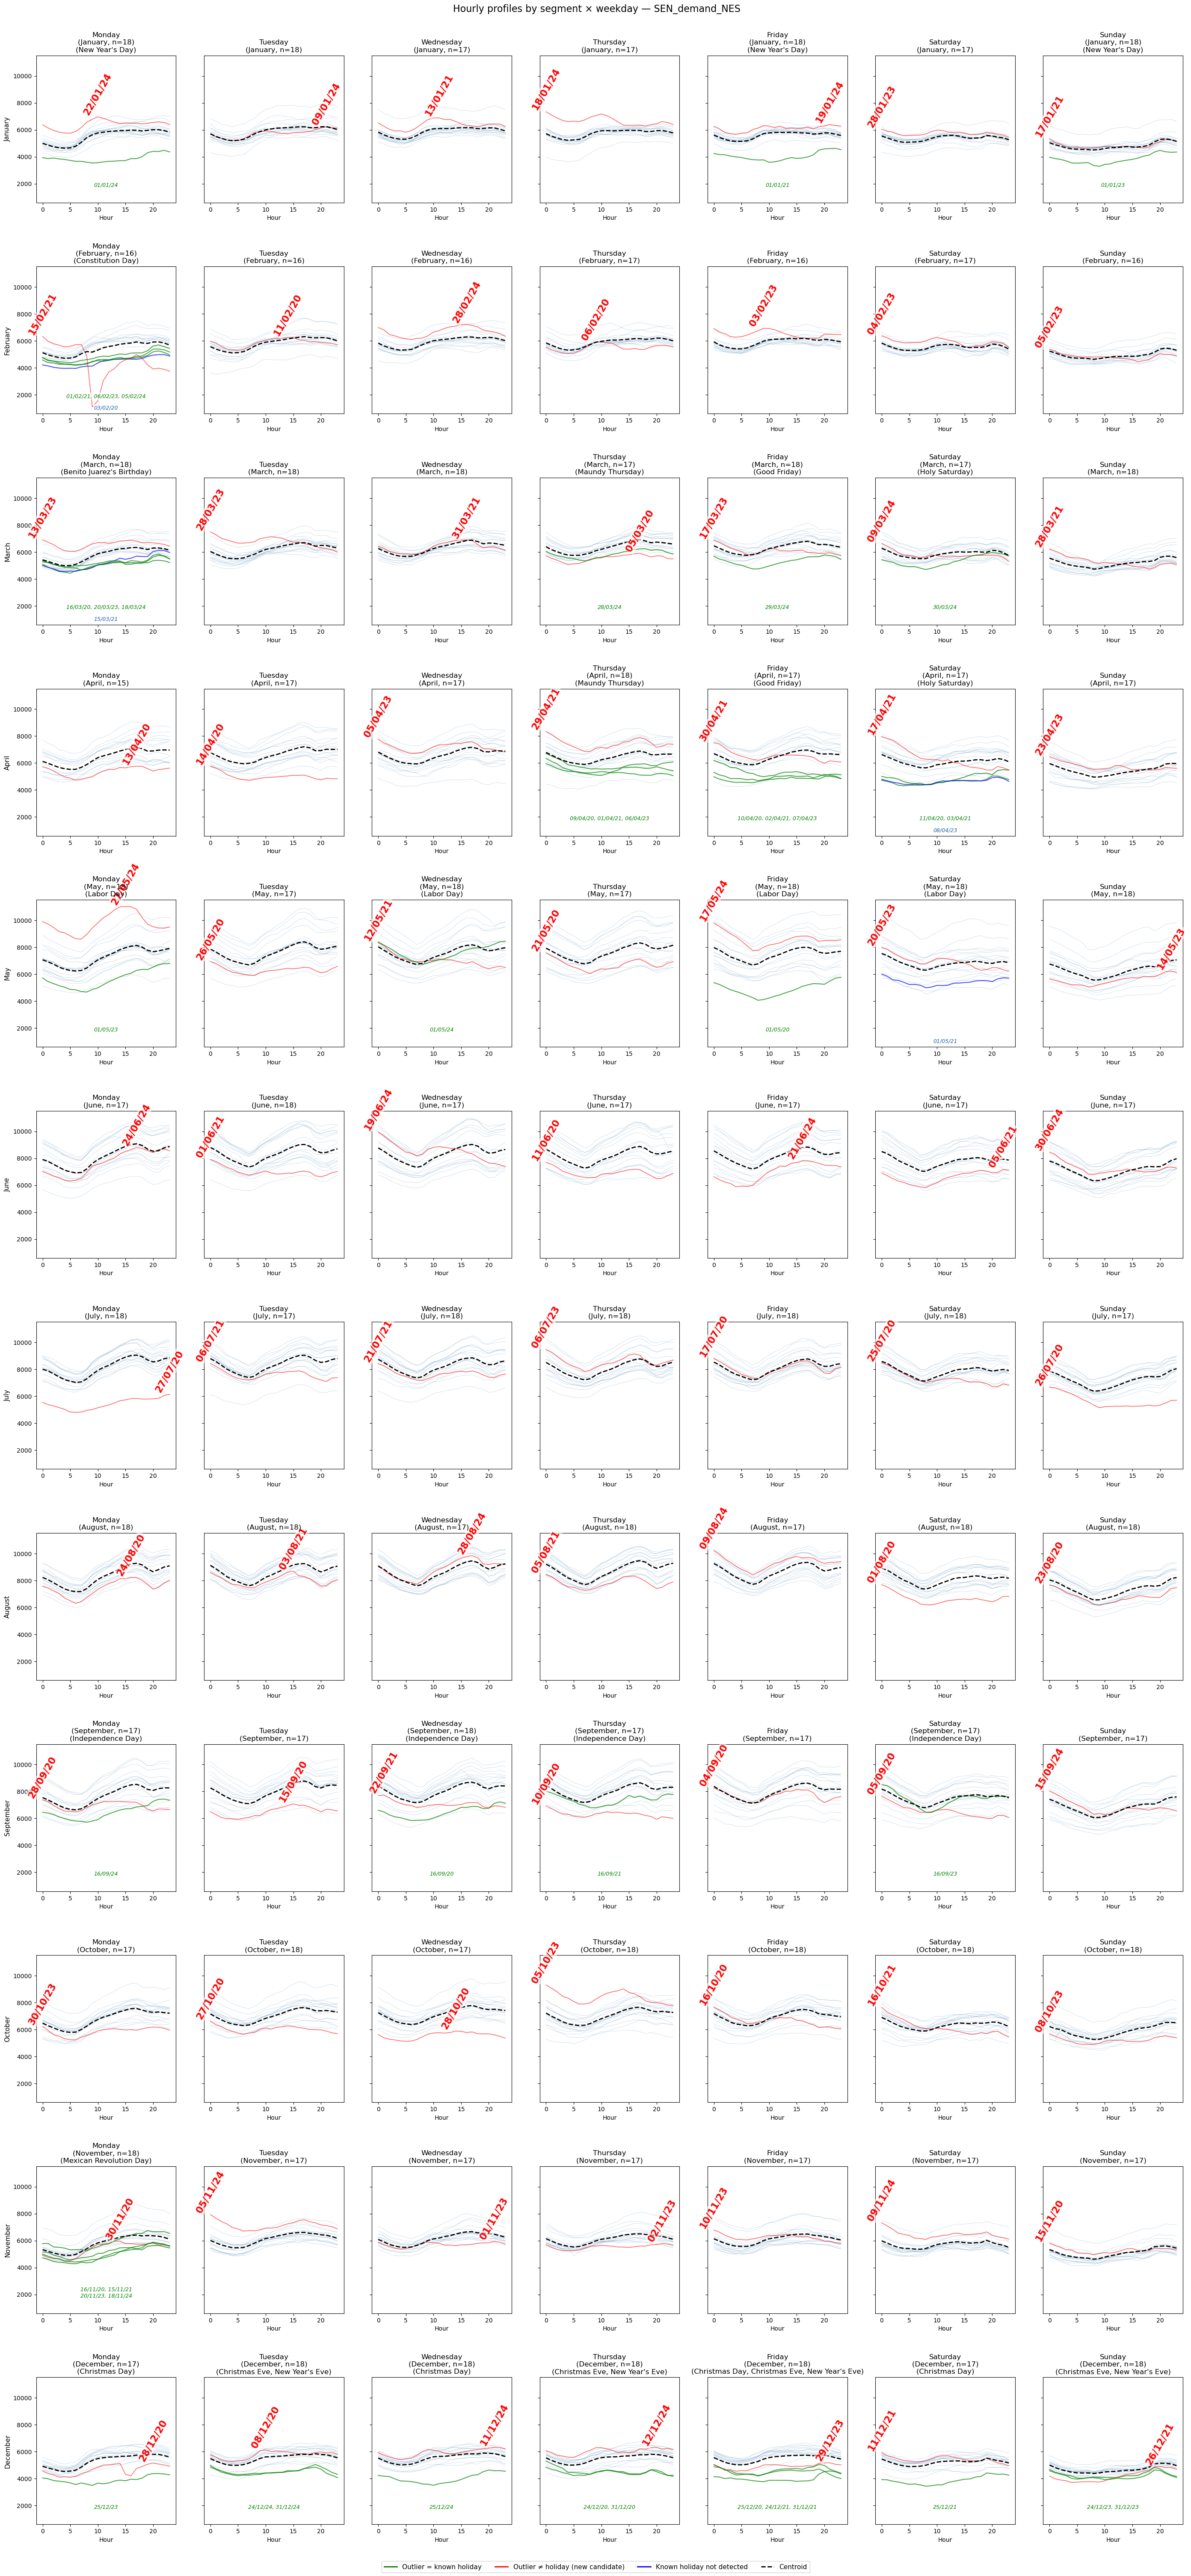

In [11]:
plot_profiles_by_segment_dow(
    df_wide, HOUR_COLS, SEGMENT_LABELS, WEEKDAY_NAMES,
    match_dates_set, unknown_dates_set, missed_dates_set, UNIQUE_ID,
    df_holidays=df_holidays_display,
)

Detected profiles use the same colors as the plotting helpers:

| Color | Meaning |
|---|---|
| Green | Detected outlier that matches a catalog holiday |
| Red | Detected outlier without a catalog match |
| Blue | Catalog holiday that was not flagged as an outlier |
| Black dashed line | Group centroid |
| Faint gray | Regular days |

## 8b. Hourly profiles by holiday

Each subplot overlays all available yearly profiles for one holiday present in the data.

| Color | Meaning |
|---|---|
| Green | Year detected as an outlier |
| Blue | Year present but not detected as an outlier |
| Black dashed line | Average holiday profile across years |

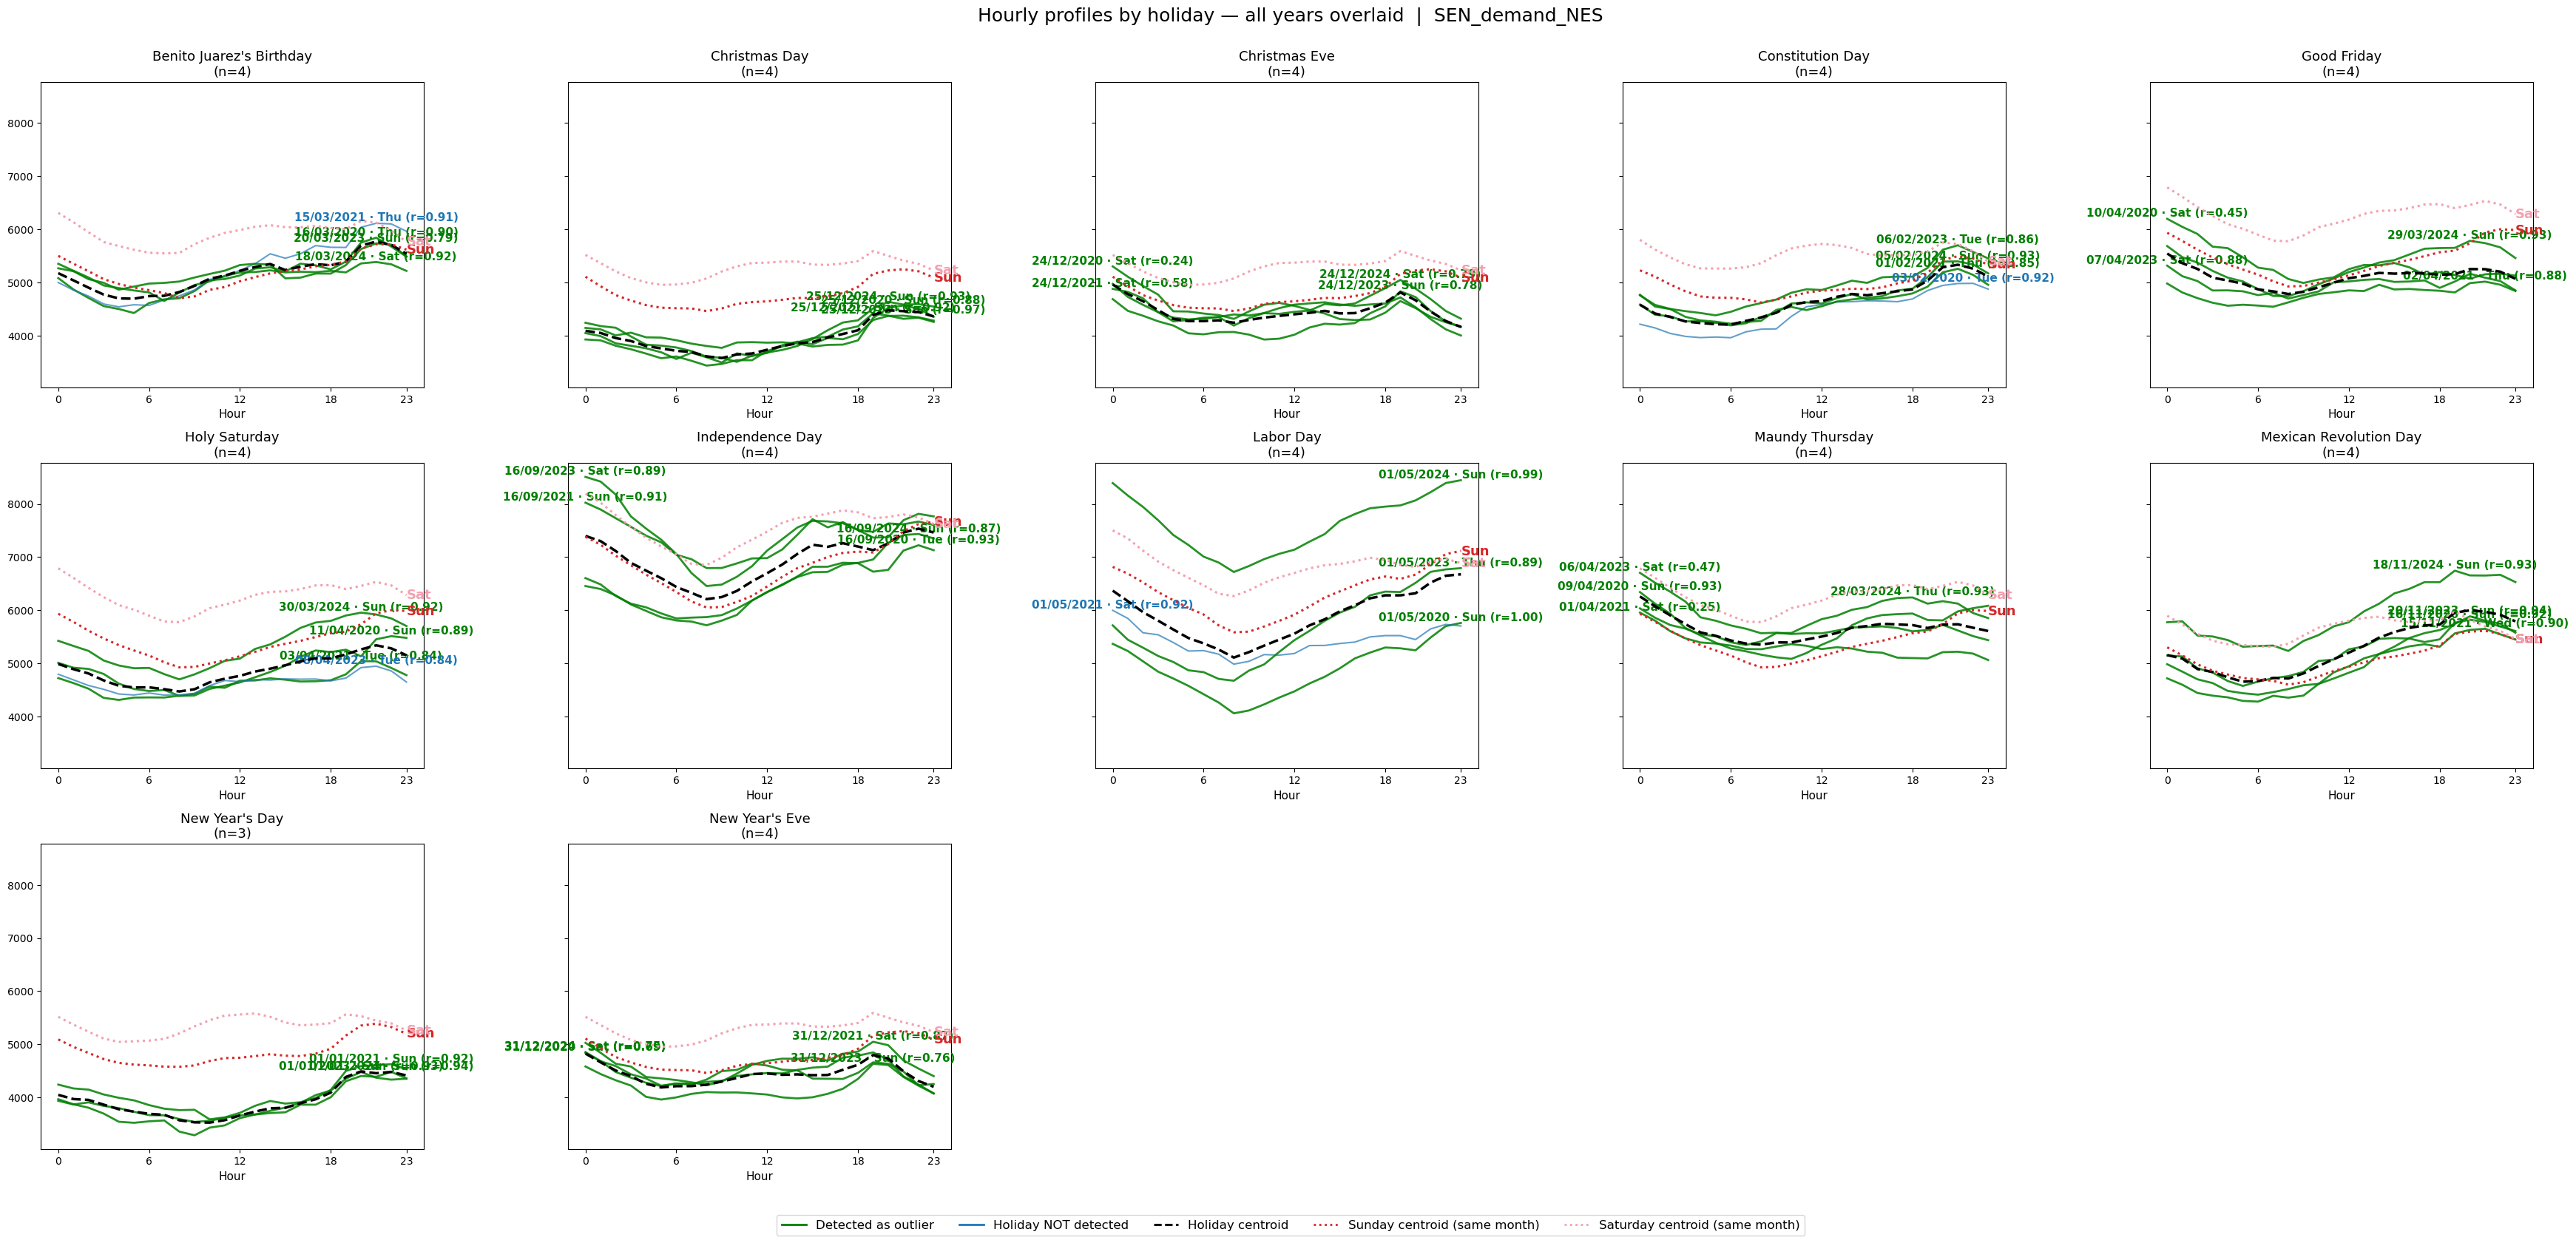

In [12]:
holiday_groups = build_holiday_groups(df_holidays_display, df_wide.index)

plot_profiles_by_holiday(
    df_wide, holiday_groups, df_holidays_display, HOUR_COLS,
    match_dates_set, outlier_dates_set, UNIQUE_ID,
)

## 8c. Cluster atypical profiles

This view clusters the detected atypical profiles and compares each cluster centroid against weekday reference profiles.

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Similarity between each cluster centroid and the weekday reference profiles


,n days,r vs Mon,r vs Tue,r vs Wed,r vs Thu,r vs Fri,r vs Sat,r vs Sun,top holidays
Cluster,,,,,,,,,
0,30,0.753,0.822,0.828,0.837,0.757,0.737,0.928,"Mexican Revolution Day, Christmas Day, Benito Juarez's Birthday"
1,13,0.038,0.283,0.332,0.357,0.391,0.819,0.542,"Christmas Eve, New Year's Eve, Good Friday"



Days per cluster


cluster,date,dow,type,holiday_name
0,2020-03-16,Mon,Confirmed holiday,Benito Juarez's Birthday
0,2020-04-09,Thu,Confirmed holiday,Maundy Thursday
0,2020-04-11,Sat,Confirmed holiday,Holy Saturday
0,2020-05-01,Fri,Confirmed holiday,Labor Day
0,2020-09-16,Wed,Confirmed holiday,Independence Day
0,2020-11-16,Mon,Confirmed holiday,Mexican Revolution Day
0,2020-12-25,Fri,Confirmed holiday,Christmas Day
0,2021-01-01,Fri,Confirmed holiday,New Year's Day
0,2021-02-01,Mon,Confirmed holiday,Constitution Day
0,2021-04-02,Fri,Confirmed holiday,Good Friday


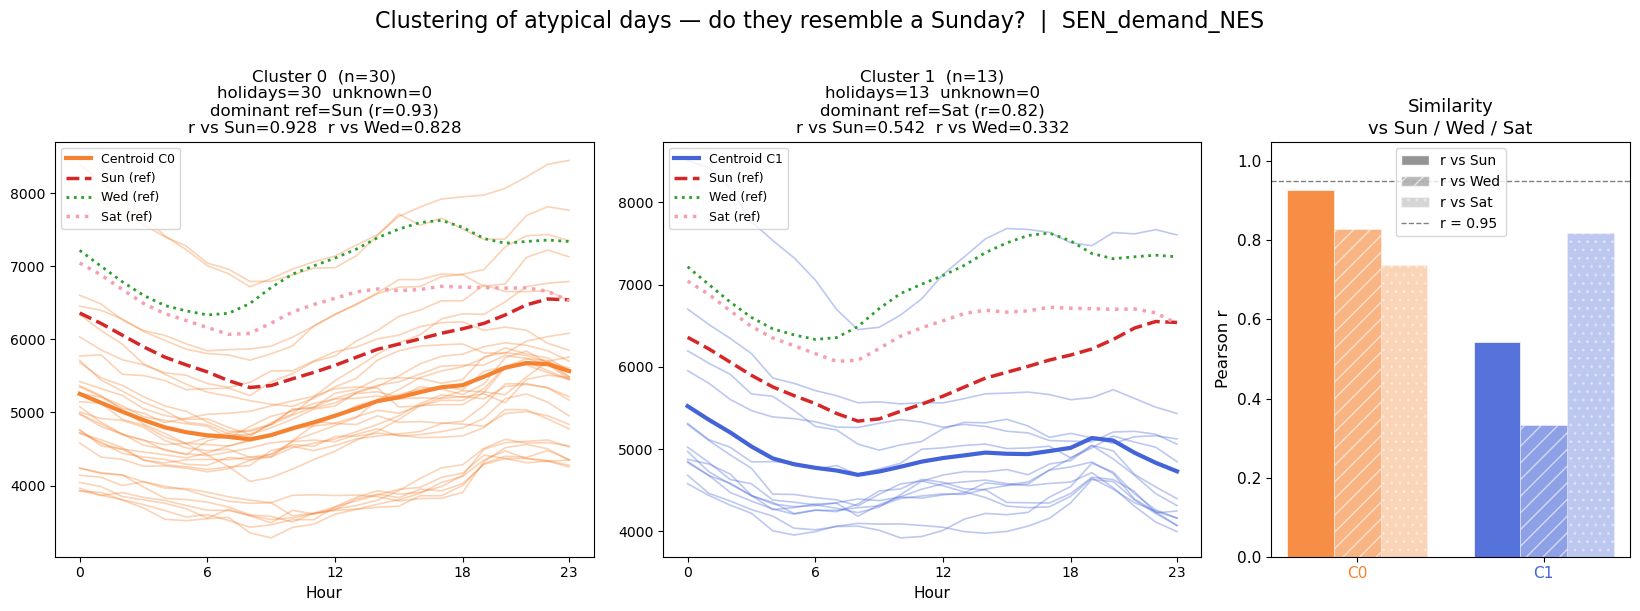

In [13]:
N_CLUSTERS = 2
CLUSTER_COLORS = [
    '#f58231',  '#4363d8', '#3cb44b', '#e6194b',
    '#911eb4', '#42d4f4', '#f032e6', '#bfef45',
]

cluster_results = run_cluster_atypical_analysis(
    df_wide,
    match_dates_set,
    set(),
    outlier_dates_set,
    N_CLUSTERS,
    HOUR_COLS,
    df_holidays_display,
    CLUSTER_COLORS,
    UNIQUE_ID,
)
df_atyp = cluster_results['df_atyp']
df_sim = cluster_results['df_sim']


## 8c-bis. Cluster: 38-h event profile (eve last 14 h + holiday 24 h)

For every confirmed holiday `D`, a single **38-hour feature vector** is built:

| Segment | Hours | Source |
|---------|-------|--------|
| Pre-holiday eve | last `PREVIOUSLY_W_HOURS = 14` h of day `D−1` (h10…h23) | `df_wide[D−1]` |
| Holiday | full 24 h of day `D` (h0…h23) | `df_wide[D]` |

KMeans is then applied to these 38-column profiles.  
Events where the eve day is missing from the data are skipped.


Events with complete 38-h profile: 42

Days per cluster


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


type,date,dow,holiday_name
C,2020-03-16,Mon,Benito Juarez's Birthday
C,2020-04-09,Thu,Maundy Thursday
C,2020-04-10,Fri,Good Friday
C,2020-09-16,Wed,Independence Day
C,2020-11-16,Mon,Mexican Revolution Day
C,2021-04-01,Thu,Maundy Thursday
C,2023-03-20,Mon,Benito Juarez's Birthday
C,2023-04-06,Thu,Maundy Thursday
C,2023-04-07,Fri,Good Friday
C,2023-05-01,Mon,Labor Day


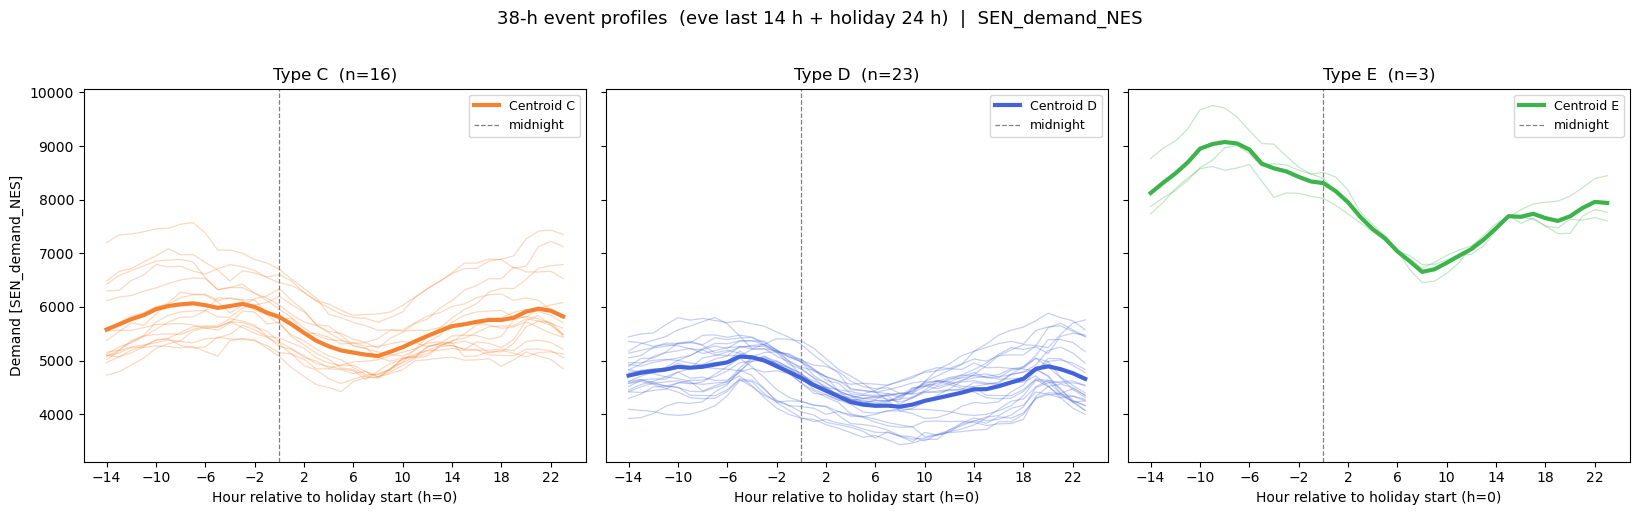

Holiday × Cluster  (38-h profiles)
Rows = holiday name   |   Columns = cluster type (count of events)



cluster_type,C,D,E
holiday_name,,,
Benito Juarez's Birthday,3,—,—
Christmas Day,—,4,—
Christmas Eve,—,4,—
Constitution Day,—,3,—
Good Friday,3,1,—
Holy Saturday,1,2,—
Independence Day,2,—,2
Labor Day,1,1,1
Maundy Thursday,4,—,—


In [14]:
cluster_38h_results = run_cluster_38h_analysis(
    df_wide=df_wide,
    match_dates_set=match_dates_set,
    df_holidays_display=df_holidays_display,
    hour_cols=HOUR_COLS,
    cluster_colors=CLUSTER_COLORS,
    unique_id=UNIQUE_ID,
    n_clusters=N_CLUSTERS_PHOL,
    previously_w_hours=PREVIOUSLY_W_HOURS,
)
df_phol      = cluster_38h_results['df_phol']
df_days_phol = cluster_38h_results['df_days_phol']

## 8d. Cluster DOW similarity

For each cluster, ranks all **7 day-of-week** reference profiles (Mon–Sun) by mean Pearson correlation, then tests statistically whether the top-ranked DOW is significantly better than the runner-up.

This avoids the ad-hoc Sat/Sun assumption: a cluster that resembles Wednesday and Sunday equally will show up as "not distinguishable", while a cluster that truly behaves like Saturday will have a clear green winner column.

| Output | Meaning |
|---|---|
| **Table 1 — mean corr** | Mean Pearson r of each cluster against each DOW centroid (same month). Green = highest, pink = lowest per row. |
| **Table 2 — votes** | Number of days in the cluster where each DOW was the best individual match. |
| **Table 3 — per-day** | Every atypical day with its 7 correlation values; green = best DOW for that day. |
| `best_dow` | DOW with highest mean r (winner). |
| `runner_up_dow` | Second-best DOW. |
| `gap_corr` | Mean r of winner minus mean r of runner-up. |
| `wilcoxon_pvalue` | One-sided Wilcoxon on (r_winner − r_runner_up) per day: p < alpha → winner is unambiguously better. |
| `cluster_type` | Winner DOW label if significant, `'unclear'` otherwise. |


In [15]:
AB_ALPHA = 0.10

cluster_ab_results = run_cluster_ab_validation(
    df_wide=df_wide,
    df_atyp=df_atyp,
    outlier_dates_set=outlier_dates_set,
    hour_cols=HOUR_COLS,
    cluster_colors=CLUSTER_COLORS,
    alpha=AB_ALPHA,
    df_holidays=df_holidays_display,
)

# cluster_type: winner DOW label (e.g. 'Sat', 'Sun') if statistically clear, else 'unclear'
cluster_type_map = dict(
    zip(
        cluster_ab_results['summary_df']['cluster'],
        cluster_ab_results['summary_df']['cluster_type'],
    )
)
print('cluster_type_map =', cluster_type_map)


Cluster DOW similarity  (alpha = 0.1)
Mean Pearson r of each cluster against the 7 DOW reference profiles.



cluster,n_days,Mon,Tue,Wed,Thu,Fri,Sat,Sun,best_dow,runner_up_dow,gap_corr,wilcoxon_pvalue,decision
0,30,0.639,0.694,0.707,0.713,0.630,0.654,0.880,Sun,Thu,0.167,0.0004,"Sun-like (Δr=0.167, p=0.0004)"
1,13,0.026,0.199,0.243,0.266,0.248,0.623,0.474,Sat,Sun,0.149,0.0164,"Sat-like (Δr=0.149, p=0.0164)"



Vote counts — best-matching DOW per day


cluster,n_days,Mon,Tue,Wed,Thu,Fri,Sat,Sun,best_dow
0,30,0,3,1,5,0,1,20,Sun
1,13,0,0,0,0,0,11,2,Sat



Per-day detail


cluster,date,profile_type,best_dow,corr_Mon,corr_Tue,corr_Wed,corr_Thu,corr_Fri,corr_Sat,corr_Sun
0,2020-03-16,Benito Juarez's Birthday,Thu,0.878,0.879,0.889,0.895,0.824,0.680,0.788
0,2020-04-09,Maundy Thursday,Sun,0.409,0.667,0.707,0.706,0.627,0.914,0.927
0,2020-04-11,Holy Saturday,Sun,0.700,0.837,0.830,0.815,0.757,0.778,0.886
0,2020-05-01,Labor Day,Sun,0.609,0.719,0.763,0.760,0.688,0.776,0.996
0,2020-09-16,Independence Day,Tue,0.888,0.934,0.916,0.905,0.867,0.778,0.876
0,2020-11-16,Mexican Revolution Day,Sun,0.846,0.859,0.895,0.863,0.835,0.732,0.917
0,2020-12-25,Christmas Day,Sun,0.191,0.193,0.207,0.250,0.081,0.375,0.879
0,2021-01-01,New Year's Day,Sun,0.141,0.193,0.138,0.108,-0.053,0.146,0.917
0,2021-02-01,Constitution Day,Thu,0.834,0.849,0.839,0.854,0.742,0.639,0.830
0,2021-04-02,Good Friday,Thu,0.823,0.876,0.871,0.879,0.858,0.769,0.589


cluster_type_map = {0: 'Sun', 1: 'Sat'}


In [16]:
df_cluster_holiday_crosstab = display_cluster_holiday_crosstab(
    df_atyp=df_atyp,
    df_holidays=df_holidays_display,
    cluster_colors=CLUSTER_COLORS,
)


Holiday × Cluster distribution
Rows = holiday name   |   Columns = cluster (count of days)



cluster,Cluster 0,Cluster 1
holiday_name,,
Benito Juarez's Birthday,3,—
Christmas Day,4,—
Christmas Eve,—,4
Constitution Day,3,—
Good Friday,2,2
Holy Saturday,3,—
Independence Day,3,1
Labor Day,3,—
Maundy Thursday,2,2


## 9. Holiday Selector Feature Schema

The selector table `df_holiday_selector_features` combines calendar rules and profile-based labels so analog candidates can be filtered or ranked by context before distance ranking.

| Field | Meaning | Typical values / source |
|---|---|---|
| `unique_id` | Demand series identifier that produced the profile labels. This keeps the exported selector series-aware when multiple regions share the same CSV. | `SEN_demand_SIN`, `OCC_demand_BAJ` |
| `holiday_name` | Name assigned to the row itself. For `H1`/`H2`/`H3` rows this is the holiday on that date. For `H4` rows this is the synthetic recovery label. | `Labor Day`, `Good Friday`, `Post-holiday recovery` |
| `anchor_holiday_name` | Anchor holiday used to identify the event family behind the row. For `H1`/`H2`/`H3` it matches `holiday_name`. For `H4` it is the last holiday in the immediately preceding run. | `Christmas Day`, `New Year's Day` |
| `date` | Calendar date represented by the row. | `2020-05-01` |
| `holiday_day_type` | H-day taxonomy label. `H1` = eve day, `H2` = core or standalone holiday, `H3` = consecutive post-holiday day, `H4` = first recovery day after a run of length >= 2. | `H1`, `H2`, `H3`, `H4` |
| `weekday_name` | Literal weekday of `date`, independent of demand similarity. | `Monday`, `Saturday`, `Sunday` |
| `day_class_code` | Compact labor-calendar code used by the selector. `1` = weekday, `2` = Saturday, `3` = Sunday. | `1`, `2`, `3` |
| `day_class_name` | Expanded text version of `day_class_code`. | `Weekday`, `Saturday`, `Sunday` |
| `season` | Meteorological season derived from the month. | `Winter`, `Spring`, `Summer`, `Autumn` |
| `date_rule` | Calendar rule behind the date. `fixed_date` = fixed official date, `observed_monday_rule` = Monday-observed civic holiday after the 2006 labor reform, `movable_date` = Easter-based movable holiday, `derived_recovery_day` = synthetic `H4` row. | `fixed_date`, `observed_monday_rule`, `movable_date`, `derived_recovery_day` |
| `is_fixed_date` | Boolean helper flag for fixed-date observances. This is also `True` for pre-2006 years of Monday-observed civic holidays, when they still fell on their original fixed date. | `True`, `False` |
| `is_observed_monday_rule` | Boolean helper flag for civic holidays shifted to Monday by the 2006 labor reform. | `True`, `False` |
| `best_matching_weekday` | Best weekday match at the individual-day level, taken from section 8d (`best_dow`) and expanded to full weekday names. This is the closest weekday profile for that specific date. | `Saturday`, `Sunday`, `Wednesday` |
| `daily_profile_cluster` | DOW-agnostic letter for the daily-profile cluster from section 8c. It is derived from `daily_profile_cluster_id` in ascending numeric order, so the current notebook typically shows `A`, `B`, etc. | `A`, `B`, `C` |
| `daily_profile_cluster_id` | Raw numeric KMeans cluster id from section 8c (atypical daily profiles). | `0`, `1`, `2` |
| `daily_profile_archetype` | Cluster-level weekday archetype inferred from section 8d (`cluster_type`). This is the human-readable interpretation of the cluster, such as `Saturday-like`, `Sunday-like`, or `unclear`. | `Saturday-like`, `Sunday-like`, `unclear` |
| `event_profile_cluster` | DOW-agnostic letter for the 38-h event-profile cluster from section 8c-bis. The current notebook typically shows `C`, `D`, `E`, etc. | `C`, `D`, `E` |
| `event_profile_cluster_id` | Raw numeric KMeans cluster id from section 8c-bis (38-h eve + holiday profile). | `0`, `1`, `2` |
| `analog_cluster_criterion` | Public criterion selected in section 11 to derive `analog_cluster` in the exported selector. This records which grouping rule produced the stable analog labels. | `seasonal_heat_cold`, `best_matching_weekday` |

Notes:

- `best_matching_weekday` is a per-date label, while `daily_profile_archetype` is a cluster-level label.
- `daily_profile_cluster` / `daily_profile_cluster_id` come from the 24-h atypical-day analysis in section 8c.
- `event_profile_cluster` / `event_profile_cluster_id` come from the 38-h eve+holiday analysis in section 8c-bis.
- `analog_cluster_criterion` is constant within one selector export and tells downstream notebooks how `analog_cluster` was derived.
- `unique_id` is exported so the selector and priors can coexist for multiple series in the same CSV without mixing labels across regions.
- `H4` rows are derived automatically and may not have event-profile labels because the 38-h clustering is defined only for confirmed holiday dates.
- Missing values in cluster-related columns are acceptable when a row was not part of the corresponding upstream analysis.
- For future candidates, profile-based labels are inferred first within the same `anchor_holiday_name` + `holiday_day_type` family and, if that subtype has no observed evidence, they fall back to the broader `anchor_holiday_name` history.

In [17]:
# 9. Holiday selector feature table (historical window for all series)
import numpy as np
from analog_holidays.shared.identify_holidays import build_holiday_selector_features

_SELECTOR_GROUP_COLS = ('unique_id', 'anchor_holiday_name', 'holiday_day_type')
_SELECTOR_DOW_LABELS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
selector_n_clusters = int(N_CLUSTERS) if 'N_CLUSTERS' in globals() else 2
selector_ab_alpha = float(AB_ALPHA) if 'AB_ALPHA' in globals() else 0.10


def _empty_cluster_ab_results():
    return {
        'occurrences_df': pd.DataFrame(),
        'summary_df': pd.DataFrame(),
        'dow_labels': list(_SELECTOR_DOW_LABELS),
    }


def _cluster_38h_profiles_no_plots(
    df_wide: pd.DataFrame,
    match_dates_set: set,
    df_holidays_local: pd.DataFrame,
    hour_cols: list,
    n_clusters: int,
    previously_w_hours: int,
) -> dict:
    cluster_labels = list('CDEFGHIJ')
    eve_hour_cols = hour_cols[-previously_w_hours:]
    hol_hour_cols = hour_cols
    feat_cols = [f'eve_{col_name}' for col_name in eve_hour_cols] + [f'hol_{col_name}' for col_name in hol_hour_cols]

    date_to_name = dict(
        zip(
            pd.to_datetime(df_holidays_local['date']).dt.normalize(),
            df_holidays_local['holiday_name'],
        )
    )
    wide_idx = set(df_wide.index.normalize())
    rows = []
    for target_date in sorted(match_dates_set):
        eve_date = target_date - pd.Timedelta(days=1)
        if eve_date not in wide_idx:
            continue
        row_eve = df_wide.loc[df_wide.index.normalize() == eve_date].squeeze()
        row_hol = df_wide.loc[df_wide.index.normalize() == target_date].squeeze()
        eve_values = row_eve[eve_hour_cols].values.astype(float)
        holiday_values = row_hol[hol_hour_cols].values.astype(float)
        if np.isnan(eve_values).any() or np.isnan(holiday_values).any():
            continue
        rows.append({
            'date': target_date,
            'holiday_name': date_to_name.get(target_date, str(target_date.date())),
            **dict(zip([f'eve_{col_name}' for col_name in eve_hour_cols], eve_values)),
            **dict(zip([f'hol_{col_name}' for col_name in hol_hour_cols], holiday_values)),
        })

    if not rows:
        df_phol = pd.DataFrame(columns=['holiday_name', *feat_cols, 'cluster', 'cluster_type'])
        df_phol.index = pd.DatetimeIndex([], name='date')
        return {
            'df_phol': df_phol,
            'df_days_phol': pd.DataFrame(columns=['type', 'date', 'dow', 'holiday_name']),
            'kmeans_phol': None,
            'centroids_phol': np.empty((0, len(feat_cols))),
            'feat_cols': feat_cols,
        }

    df_phol = pd.DataFrame(rows).set_index('date')
    resolved_n_clusters = min(int(n_clusters), len(df_phol))
    profiles = df_phol[feat_cols].values.astype(float)
    profiles_scaled = identify_holidays_module.StandardScaler().fit_transform(profiles)
    kmeans_phol = identify_holidays_module.KMeans(
        n_clusters=resolved_n_clusters,
        random_state=42,
        n_init=20,
    ).fit(profiles_scaled)
    df_phol['cluster'] = kmeans_phol.labels_
    df_phol['cluster_type'] = [cluster_labels[label] for label in kmeans_phol.labels_]

    centroids_phol = np.array([
        df_phol.loc[df_phol['cluster'] == cluster_id, feat_cols].values.mean(axis=0)
        for cluster_id in range(resolved_n_clusters)
    ])

    df_days_phol = (
        pd.DataFrame(
            [
                {
                    'type': row['cluster_type'],
                    'date': date_value,
                    'dow': date_value.day_name()[:3],
                    'holiday_name': row['holiday_name'],
                }
                for date_value, row in df_phol.iterrows()
            ]
        )
        .sort_values(['type', 'date'])
        .reset_index(drop=True)
    )

    return {
        'df_phol': df_phol,
        'df_days_phol': df_days_phol,
        'kmeans_phol': kmeans_phol,
        'centroids_phol': centroids_phol,
        'feat_cols': feat_cols,
    }


def _build_selector_history_for_unique_id(unique_id: str) -> dict:
    df_raw_full = load_results_data(DEMAND_PATH, unique_id)
    available_dates_full = set(df_raw_full['ds'].dt.normalize())

    df_raw_local = df_raw_full.copy()
    if DATE_END is not None:
        cutoff_ts = pd.Timestamp(DATE_END)
        df_raw_local = df_raw_local[df_raw_local['ds'] < cutoff_ts].copy()
    if df_raw_local.empty:
        raise ValueError(f'No data available for {unique_id} inside the historical selector window.')

    df_wide_local = build_wide_df(df_raw_local, MONTH_TO_SEGMENT, exclude_years=[2022])
    if df_wide_local.empty:
        raise ValueError(f'No complete daily profiles are available for {unique_id}.')

    hour_cols_local = get_hour_cols(df_wide_local)
    year_min_local = int(df_wide_local.index.year.min())
    year_max_local = int(df_wide_local.index.year.max())
    df_holidays_local = load_holidays_catalog(HOLIDAYS_PATH, year_min_local, year_max_local)
    known_holiday_dates_local = (
        set(pd.to_datetime(df_holidays_local['date']).dt.normalize())
        if EXCLUDE_KNOWN_HOLIDAYS_FROM_BASELINE else set()
    )

    df_dist_local = compute_distances(
        df_wide_local,
        hour_cols_local,
        SEGMENT_LABELS,
        WEEKDAY_NAMES,
        distance_metric=DISTANCE_METRIC,
        reference_exclude_dates=known_holiday_dates_local,
    )
    df_dist_local, df_outliers_local = detect_outliers(
        df_dist_local,
        OUTLIER_PERCENTILE,
        threshold_reference_only=EXCLUDE_KNOWN_HOLIDAYS_FROM_BASELINE,
        promote_dates=known_holiday_dates_local,
        promote_min_group_percentile=KNOWN_HOLIDAY_MIN_GROUP_PERCENTILE,
    )
    df_match_local, _ = compare_outliers_holidays(df_outliers_local, df_holidays_local)
    all_dates_local = set(df_wide_local.index.normalize())
    date_sets_local = get_date_sets(df_match_local, df_holidays_local, all_dates_local)

    match_dates_set_local = date_sets_local['match_dates_set']
    unknown_dates_set_local = date_sets_local['unknown_dates_set']
    outlier_dates_set_local = date_sets_local['outlier_dates_set']
    atypical_dates_local = match_dates_set_local | unknown_dates_set_local

    if atypical_dates_local:
        cluster_results_local = identify_holidays_module.cluster_atypical_profiles(
            df_wide_local,
            match_dates_set_local,
            unknown_dates_set_local,
            outlier_dates_set_local,
            min(selector_n_clusters, len(atypical_dates_local)),
            hour_cols_local,
            df_holidays_local,
        )
        cluster_ab_results_local = identify_holidays_module.classify_cluster_dow_type(
            df_wide_local,
            cluster_results_local['df_atyp'],
            outlier_dates_set_local,
            hour_cols_local,
            selector_ab_alpha,
        )
    else:
        cluster_ab_results_local = _empty_cluster_ab_results()

    cluster_38h_results_local = _cluster_38h_profiles_no_plots(
        df_wide_local,
        match_dates_set_local,
        df_holidays_local,
        hour_cols_local,
        N_CLUSTERS_PHOL,
        PREVIOUSLY_W_HOURS,
    )

    df_selector_history_local = build_holiday_selector_features(
        df_wide=df_wide_local,
        df_holidays=df_holidays_local,
        cluster_ab_results=cluster_ab_results_local,
        df_phol=cluster_38h_results_local['df_phol'],
        holidays_path=HOLIDAYS_PATH,
        unique_id=unique_id,
    )

    print(
        f'[{unique_id}] complete days={len(df_wide_local)} | '
        f'history selector rows={len(df_selector_history_local)} | '
        f'matched holidays={len(match_dates_set_local)}'
    )
    return {
        'unique_id': unique_id,
        'selector_history': df_selector_history_local,
        'available_dates_full': available_dates_full,
    }


selector_series_contexts = {}
selector_history_frames = []
for series_unique_id in AVAILABLE_UNIQUE_IDS:
    selector_context = _build_selector_history_for_unique_id(series_unique_id)
    selector_series_contexts[series_unique_id] = selector_context
    selector_history_frames.append(selector_context['selector_history'])

df_holiday_selector_features_history_all = (
    pd.concat(selector_history_frames, ignore_index=True)
    .sort_values(['unique_id', 'date', 'holiday_name'])
    .reset_index(drop=True)
)
df_holiday_selector_features_history = (
    df_holiday_selector_features_history_all
    .loc[df_holiday_selector_features_history_all['unique_id'] == UNIQUE_ID]
    .copy()
    .reset_index(drop=True)
)

selector_history_counts = (
    df_holiday_selector_features_history_all
    .groupby('unique_id', dropna=False)
    .size()
    .rename('historical_rows')
    .reset_index()
    .sort_values('unique_id')
    .reset_index(drop=True)
)

print(f'Historical selector rows ({UNIQUE_ID}): {len(df_holiday_selector_features_history)}')
print(
    f'Historical selector rows (all series): {len(df_holiday_selector_features_history_all)} '
    f'| series={df_holiday_selector_features_history_all["unique_id"].nunique()}'
)
display(selector_history_counts)
display(df_holiday_selector_features_history)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


[SEN_demand_SIN] complete days=1459 | history selector rows=57 | matched holidays=47


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


[SEN_demand_CEL] complete days=1459 | history selector rows=57 | matched holidays=46


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


...

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


[SEN_demand_NTE] complete days=1459 | history selector rows=57 | matched holidays=46
Historical selector rows (SEN_demand_NES): 57
Historical selector rows (all series): 456 | series=8


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,unique_id,historical_rows
0,SEN_demand_CEL,57
1,SEN_demand_NES,57
2,SEN_demand_NOR,57
3,SEN_demand_NTE,57
4,SEN_demand_OCC,57
5,SEN_demand_ORI,57
6,SEN_demand_PEN,57
7,SEN_demand_SIN,57


,unique_id,holiday_name,anchor_holiday_name,date,holiday_day_type,weekday_name,day_class_code,day_class_name,season,date_rule,is_fixed_date,is_observed_monday_rule,best_matching_weekday,daily_profile_cluster,daily_profile_cluster_id,daily_profile_archetype,event_profile_cluster,event_profile_cluster_id
0,SEN_demand_NES,Constitution Day,Constitution Day,2020-02-03,H2,Monday,1,Weekday,Winter,observed_monday_rule,False,True,NaN,NaN,<NA>,NaN,NaN,<NA>
1,SEN_demand_NES,Benito Juarez's Birthday,Benito Juarez's Birthday,2020-03-16,H2,Monday,1,Weekday,Spring,observed_monday_rule,False,True,Thursday,B,1,unclear,C,0
2,SEN_demand_NES,Maundy Thursday,Maundy Thursday,2020-04-09,H1,Thursday,1,Weekday,Spring,movable_date,False,False,Sunday,B,1,unclear,C,0
3,SEN_demand_NES,Good Friday,Good Friday,2020-04-10,H2,Friday,1,Weekday,Spring,movable_date,False,False,Saturday,A,0,Saturday-like,C,0
4,SEN_demand_NES,Holy Saturday,Holy Saturday,2020-04-11,H3,Saturday,2,Saturday,Spring,movable_date,False,False,Sunday,B,1,unclear,D,1
5,SEN_demand_NES,Post-holiday recovery,Holy Saturday,2020-04-12,H4,Sunday,3,Sunday,Spring,derived_recovery_day,False,False,NaN,NaN,<NA>,NaN,NaN,<NA>
6,SEN_demand_NES,Labor Day,Labor Day,2020-05-01,H2,Friday,1,Weekday,Spring,fixed_date,True,False,Sunday,B,1,unclear,D,1
7,SEN_demand_NES,Independence Day,Independence Day,2020-09-16,H2,Wednesday,1,Weekday,Autumn,fixed_date,True,False,Tuesday,B,1,unclear,C,0
8,SEN_demand_NES,Mexican Revolution Day,Mexican Revolution Day,2020-11-16,H2,Monday,1,Weekday,Autumn,observed_monday_rule,False,True,Sunday,B,1,unclear,C,0
9,SEN_demand_NES,Christmas Eve,Christmas Eve,2020-12-24,H1,Thursday,1,Weekday,Winter,fixed_date,True,False,Saturday,A,0,Saturday-like,D,1


In [18]:
# 10. Ex-ante profile priors for new candidates
# Priors are estimated on the historical selector rows of all available series.
from analog_holidays.shared.identify_holidays import (
    build_future_holiday_selector_features,
    build_holiday_selector_priors,
)

selector_features_path = Path('holidays') / 'holiday_selector_features.csv'
selector_priors_path = Path('holidays') / 'holiday_selector_priors.csv'

if 'selector_series_contexts' not in globals() or not selector_series_contexts:
    raise ValueError('Run Cell 33 first to build the per-series historical selector contexts.')

df_holiday_selector_priors = build_holiday_selector_priors(
    df_holiday_selector_features_history_all,
    group_cols=_SELECTOR_GROUP_COLS,
)

selector_future_start = (
    pd.Timestamp(DATE_END).normalize()
    if DATE_END is not None
    else pd.to_datetime(df_holiday_selector_features_history_all['date']).max().normalize() + pd.Timedelta(days=1)
)
selector_future_end = pd.Timestamp(SELECTOR_FUTURE_END).normalize() if SELECTOR_FUTURE_END is not None else None
future_year_end = (
    int(selector_future_end.year)
    if selector_future_end is not None
    else int(pd.to_datetime(df_holiday_selector_features_history_all['date']).max().year)
)
df_holidays_selector_source = load_holidays_catalog(
    HOLIDAYS_PATH,
    year_min,
    future_year_end,
)

future_frames = []
for series_unique_id, series_context in selector_series_contexts.items():
    df_future_local = build_future_holiday_selector_features(
        df_holidays=df_holidays_selector_source,
        df_priors=df_holiday_selector_priors,
        available_dates=series_context['available_dates_full'],
        holidays_path=HOLIDAYS_PATH,
        group_cols=_SELECTOR_GROUP_COLS,
        start_date=selector_future_start,
        end_date=selector_future_end,
        unique_id=series_unique_id,
    )
    future_frames.append(df_future_local)
    print(f'[{series_unique_id}] future ex-ante rows={len(df_future_local)}')

df_holiday_selector_features_future_all = (
    pd.concat(future_frames, ignore_index=True)
    .sort_values(['unique_id', 'date', 'holiday_name'])
    .reset_index(drop=True)
    if future_frames else pd.DataFrame(columns=df_holiday_selector_features_history_all.columns)
)
df_holiday_selector_features_future = (
    df_holiday_selector_features_future_all
    .loc[df_holiday_selector_features_future_all['unique_id'] == UNIQUE_ID]
    .copy()
    .reset_index(drop=True)
)

df_holiday_selector_features = (
    pd.concat(
        [df_holiday_selector_features_history_all, df_holiday_selector_features_future_all],
        ignore_index=True,
    )
    .sort_values(['unique_id', 'date', 'holiday_name'])
    .reset_index(drop=True)
)

df_holiday_selector_features_export = df_holiday_selector_features.copy()
df_holiday_selector_features_export['date'] = (
    pd.to_datetime(df_holiday_selector_features_export['date'])
    .dt.strftime('%Y-%m-%d')
)
df_holiday_selector_features_export.to_csv(selector_features_path, index=False)

df_holiday_selector_priors_export = df_holiday_selector_priors.copy()
df_holiday_selector_priors_export.to_csv(selector_priors_path, index=False)

selector_future_counts = (
    df_holiday_selector_features_future_all
    .groupby('unique_id', dropna=False)
    .size()
    .rename('future_rows')
    .reset_index()
    .sort_values('unique_id')
    .reset_index(drop=True)
    if not df_holiday_selector_features_future_all.empty else pd.DataFrame(columns=['unique_id', 'future_rows'])
)

print(f'Historical selector rows ({UNIQUE_ID}): {len(df_holiday_selector_features_history)}')
print(f'Future ex-ante rows ({UNIQUE_ID}): {len(df_holiday_selector_features_future)}')
print(f'Total selector rows exported: {len(df_holiday_selector_features_export)}')
print(
    f'Series exported: {df_holiday_selector_features_export["unique_id"].nunique()} '
    f'| selector_future_start={selector_future_start.date()} '
    f'| selector_future_end={selector_future_end.date() if selector_future_end is not None else "source max"}'
)
print(f'Selector CSV saved to: {selector_features_path.resolve()}')
print(f'Priors CSV saved to: {selector_priors_path.resolve()}')
display(selector_future_counts)
display(
    df_holiday_selector_priors
    .loc[df_holiday_selector_priors['unique_id'] == UNIQUE_ID]
    .reset_index(drop=True)
)
display(df_holiday_selector_features_future)

[SEN_demand_SIN] future ex-ante rows=24
[SEN_demand_CEL] future ex-ante rows=24
[SEN_demand_OCC] future ex-ante rows=24
[SEN_demand_NOR] future ex-ante rows=24
[SEN_demand_PEN] future ex-ante rows=24
[SEN_demand_ORI] future ex-ante rows=24
[SEN_demand_NES] future ex-ante rows=24
[SEN_demand_NTE] future ex-ante rows=24
Historical selector rows (SEN_demand_NES): 57
Future ex-ante rows (SEN_demand_NES): 24
Total selector rows exported: 648
Series exported: 8 | selector_future_start=2025-01-01 | selector_future_end=2026-12-31
Selector CSV saved to: C:\GIT\analog_holidays\holidays\holiday_selector_features.csv
Priors CSV saved to: C:\GIT\analog_holidays\holidays\holiday_selector_priors.csv


,unique_id,future_rows
0,SEN_demand_CEL,24
1,SEN_demand_NES,24
2,SEN_demand_NOR,24
3,SEN_demand_NTE,24
4,SEN_demand_OCC,24
5,SEN_demand_ORI,24
6,SEN_demand_PEN,24
7,SEN_demand_SIN,24


,unique_id,anchor_holiday_name,holiday_day_type,history_rows,history_years,inferred_best_matching_weekday,inferred_daily_profile_cluster,inferred_daily_profile_cluster_id,inferred_daily_profile_archetype,inferred_event_profile_cluster,inferred_event_profile_cluster_id
0,SEN_demand_NES,Benito Juarez's Birthday,H2,4,4,Saturday,B,1,unclear,C,0
1,SEN_demand_NES,Christmas Day,H2,4,4,Sunday,B,1,unclear,D,1
2,SEN_demand_NES,Christmas Day,H4,4,4,Sunday,B,1,unclear,D,1
3,SEN_demand_NES,Christmas Eve,H1,4,4,Saturday,A,0,Saturday-like,D,1
4,SEN_demand_NES,Constitution Day,H2,4,4,Sunday,B,1,unclear,D,1
5,SEN_demand_NES,Good Friday,H2,4,4,Saturday,B,1,unclear,C,0
6,SEN_demand_NES,Holy Saturday,H3,4,4,Sunday,B,1,unclear,D,1
7,SEN_demand_NES,Holy Saturday,H4,4,4,Sunday,B,1,unclear,D,1
8,SEN_demand_NES,Independence Day,H2,4,4,Sunday,A,0,Saturday-like,C,0
9,SEN_demand_NES,Labor Day,H2,4,4,Sunday,B,1,unclear,C,0


,unique_id,holiday_name,anchor_holiday_name,date,holiday_day_type,weekday_name,day_class_code,day_class_name,season,date_rule,is_fixed_date,is_observed_monday_rule,best_matching_weekday,daily_profile_cluster,daily_profile_cluster_id,daily_profile_archetype,event_profile_cluster,event_profile_cluster_id
0,SEN_demand_NES,New Year's Day,New Year's Day,2025-01-01,H3,Wednesday,1,Weekday,Winter,fixed_date,True,False,Sunday,B,1,unclear,D,1
1,SEN_demand_NES,Post-holiday recovery,New Year's Day,2025-01-02,H4,Thursday,1,Weekday,Winter,derived_recovery_day,False,False,Sunday,B,1,unclear,D,1
2,SEN_demand_NES,Constitution Day,Constitution Day,2025-02-03,H2,Monday,1,Weekday,Winter,observed_monday_rule,False,True,Sunday,B,1,unclear,D,1
3,SEN_demand_NES,Benito Juarez's Birthday,Benito Juarez's Birthday,2025-03-17,H2,Monday,1,Weekday,Spring,observed_monday_rule,False,True,Saturday,B,1,unclear,C,0
4,SEN_demand_NES,Maundy Thursday,Maundy Thursday,2025-04-17,H1,Thursday,1,Weekday,Spring,movable_date,False,False,Saturday,A,0,Saturday-like,C,0
5,SEN_demand_NES,Good Friday,Good Friday,2025-04-18,H2,Friday,1,Weekday,Spring,movable_date,False,False,Saturday,B,1,unclear,C,0
6,SEN_demand_NES,Holy Saturday,Holy Saturday,2025-04-19,H3,Saturday,2,Saturday,Spring,movable_date,False,False,Sunday,B,1,unclear,D,1
7,SEN_demand_NES,Post-holiday recovery,Holy Saturday,2025-04-20,H4,Sunday,3,Sunday,Spring,derived_recovery_day,False,False,Sunday,B,1,unclear,D,1
8,SEN_demand_NES,Labor Day,Labor Day,2025-05-01,H2,Thursday,1,Weekday,Spring,fixed_date,True,False,Sunday,B,1,unclear,C,0
9,SEN_demand_NES,Independence Day,Independence Day,2025-09-16,H2,Tuesday,1,Weekday,Autumn,fixed_date,True,False,Sunday,A,0,Saturday-like,C,0


## 11. Analog-Space Clusters (`F`, `G`, `H`, ...)

Use `CLUSTERING_CRITERIUM` to choose how daily selector rows are grouped into stable analog-space labels.

The public criterion catalog exposed in this notebook currently includes `shape_pearson_CDE_map_FGH`, `seasonal_heat_cold`, `seasonal_winter_sprint_fall`, and `best_matching_weekday`. The binary seasonal option collapses Spring/Summer into heat and Autumn/Winter into cold.

Historical rows determine the analog-space mapping. Future holiday rows in the 2025/2026 test horizon receive their profile labels ex-ante from `holiday_selector_priors.csv`, so the exported selector can be filled without using future observations.

The selector export `holidays/holiday_selector_features.csv` is the single source of truth for daily `analog_cluster` labels. No hourly `*_cluster` columns are added to the demand source anymore.

In [19]:
from analog_holidays.shared.identify_holidays import assign_holiday_selector_analog_clusters

analog_cluster_results = assign_holiday_selector_analog_clusters(
    df_selector=df_holiday_selector_features,
    df_priors=df_holiday_selector_priors,
    criterion=CLUSTERING_CRITERIUM,
    group_cols=_SELECTOR_GROUP_COLS,
    cluster_labels=('F', 'G', 'H'),
)
df_holiday_selector_analog_clusters = analog_cluster_results['df_selector_clusters']
df_analog_cluster_catalog = analog_cluster_results['analog_cluster_catalog']
analog_criterion_prior_col = analog_cluster_results.get('analog_criterion_prior_col')

drop_columns = [
    'analog_criterion',
    'analog_criterion_value',
]
if analog_criterion_prior_col is not None:
    drop_columns.append(analog_criterion_prior_col)

df_holiday_selector_features = (
    df_holiday_selector_analog_clusters
    .drop(columns=drop_columns, errors='ignore')
    .assign(analog_cluster_criterion=CLUSTERING_CRITERIUM)
    .sort_values(['unique_id', 'date', 'holiday_name'])
    .reset_index(drop=True)
)
df_holiday_selector_features_current = (
    df_holiday_selector_features
    .loc[df_holiday_selector_features['unique_id'] == UNIQUE_ID]
    .copy()
    .reset_index(drop=True)
)

_analog_cluster_by_date = (
    df_holiday_selector_features_current[['date', 'analog_cluster']]
    .dropna(subset=['analog_cluster'])
    .drop_duplicates(subset=['date'])
    .copy()
)
_analog_cluster_by_date['date'] = pd.to_datetime(_analog_cluster_by_date['date']).dt.normalize()

df_holidays_display = (
    df_holidays_display
    .drop(columns=['analog_cluster'], errors='ignore')
    .merge(_analog_cluster_by_date, on='date', how='left')
)

df_holiday_selector_features_export = df_holiday_selector_features.copy()
if 'date' in df_holiday_selector_features_export.columns:
    df_holiday_selector_features_export['date'] = (
        pd.to_datetime(df_holiday_selector_features_export['date'])
        .dt.strftime('%Y-%m-%d')
    )
df_holiday_selector_features_export.to_csv(selector_features_path, index=False)

df_analog_cluster_summary = (
    df_holiday_selector_features
    .dropna(subset=['analog_cluster'])
    .groupby(['unique_id', 'analog_cluster'], dropna=False)
    .size()
    .rename('n_rows')
    .reset_index()
    .sort_values(['unique_id', 'analog_cluster'])
    .reset_index(drop=True)
)

print(f'Analog-cluster criterion: {CLUSTERING_CRITERIUM}')
print(f'Catalog rows: {len(df_analog_cluster_catalog)}')
print(
    f'Analog labels exported: {tuple(df_analog_cluster_catalog["analog_cluster"].astype(str).tolist())}'
)
print(
    f'Selector CSV saved to: {selector_features_path.resolve()} '
    f'| series exported={df_holiday_selector_features_export["unique_id"].nunique()}'
)
print('df_holidays_display updated with analog_cluster for the current detail-view series. Re-run the figure cells in sections 7 and 8 to see labels like [F].')
display(df_analog_cluster_catalog)
display(df_analog_cluster_summary)
display(
    df_holiday_selector_features_current[
        [
            'unique_id',
            'holiday_name',
            'anchor_holiday_name',
            'date',
            'holiday_day_type',
            'event_profile_cluster',
            'analog_cluster_criterion',
            'analog_cluster',
        ]
    ].sort_values('date').reset_index(drop=True)
)

Analog-cluster criterion: best_matching_weekday
Catalog rows: 7
Analog labels exported: ('F', 'G', 'H', 'I', 'J', 'K', 'L')
Selector CSV saved to: C:\GIT\analog_holidays\holidays\holiday_selector_features.csv | series exported=8
df_holidays_display updated with analog_cluster for the current detail-view series. Re-run the figure cells in sections 7 and 8 to see labels like [F].


,analog_cluster,analog_criterion,analog_criterion_value,n_rows,n_anchor_holidays
0,F,best_matching_weekday,Friday,1,1
1,G,best_matching_weekday,Monday,49,5
2,H,best_matching_weekday,Saturday,153,11
3,I,best_matching_weekday,Sunday,382,12
4,J,best_matching_weekday,Thursday,15,7
5,K,best_matching_weekday,Tuesday,33,7
6,L,best_matching_weekday,Wednesday,15,7


,unique_id,analog_cluster,n_rows
0,SEN_demand_CEL,H,20
1,SEN_demand_CEL,I,61
2,SEN_demand_NES,H,21
3,SEN_demand_NES,I,51
4,SEN_demand_NES,J,5
5,SEN_demand_NES,K,3
6,SEN_demand_NES,L,1
7,SEN_demand_NOR,G,4
8,SEN_demand_NOR,H,14
9,SEN_demand_NOR,I,54


,unique_id,holiday_name,anchor_holiday_name,date,holiday_day_type,event_profile_cluster,analog_cluster_criterion,analog_cluster
0,SEN_demand_NES,Constitution Day,Constitution Day,2020-02-03,H2,NaN,best_matching_weekday,I
1,SEN_demand_NES,Benito Juarez's Birthday,Benito Juarez's Birthday,2020-03-16,H2,C,best_matching_weekday,J
2,SEN_demand_NES,Maundy Thursday,Maundy Thursday,2020-04-09,H1,C,best_matching_weekday,I
3,SEN_demand_NES,Good Friday,Good Friday,2020-04-10,H2,C,best_matching_weekday,H
4,SEN_demand_NES,Holy Saturday,Holy Saturday,2020-04-11,H3,D,best_matching_weekday,I
...,...,...,...,...,...,...,...,...
76,SEN_demand_NES,Maundy Thursday,Maundy Thursday,2026-04-02,H1,C,best_matching_weekday,H
77,SEN_demand_NES,Good Friday,Good Friday,2026-04-03,H2,C,best_matching_weekday,H
78,SEN_demand_NES,Holy Saturday,Holy Saturday,2026-04-04,H3,D,best_matching_weekday,I
79,SEN_demand_NES,Post-holiday recovery,Holy Saturday,2026-04-05,H4,D,best_matching_weekday,I



Days per analog cluster


type,date,dow,holiday_name,cluster_38h
H,2020-12-24,Thu,Christmas Eve,D
H,2020-12-31,Thu,New Year's Eve,D
H,2021-04-01,Thu,Maundy Thursday,C
H,2021-04-02,Fri,Good Friday,D
H,2021-04-03,Sat,Holy Saturday,D
H,2021-12-24,Fri,Christmas Eve,D
H,2021-12-31,Fri,New Year's Eve,D
H,2023-04-06,Thu,Maundy Thursday,C
H,2024-03-18,Mon,Benito Juarez's Birthday,C
H,2024-03-28,Thu,Maundy Thursday,C


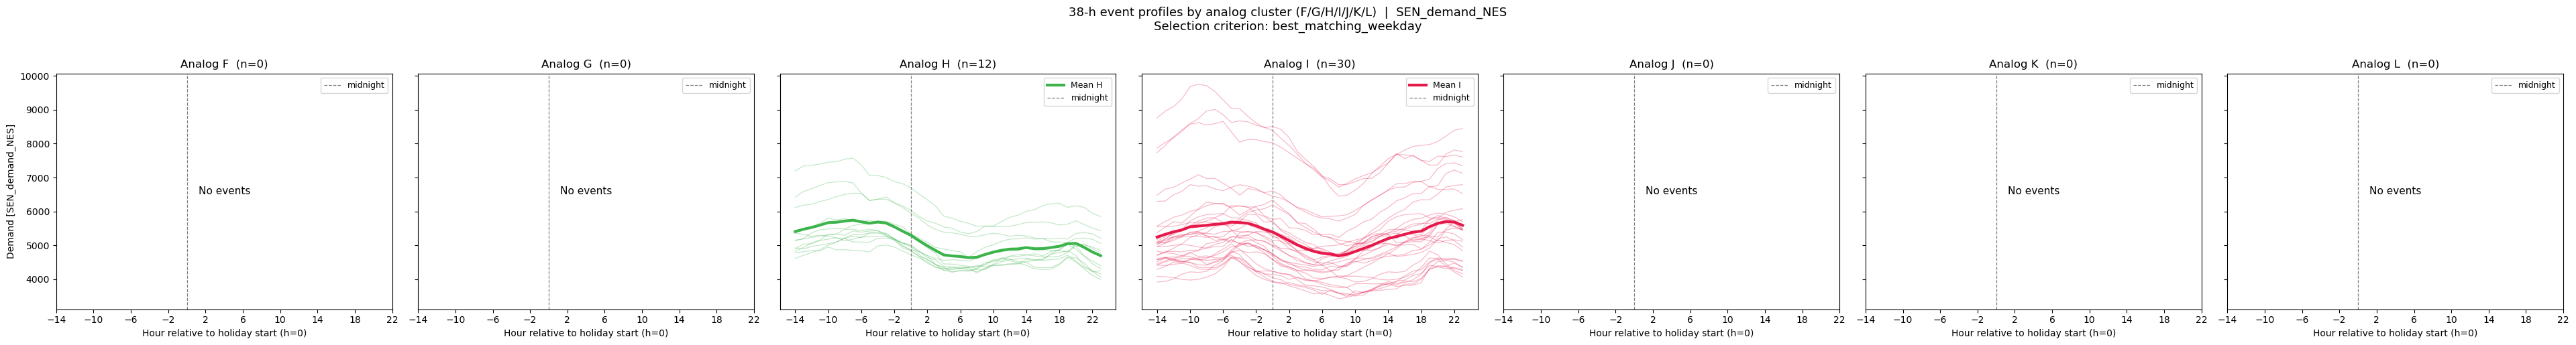

Analog-cluster profiles available: 42


In [20]:
analog_cluster_labels = tuple(
    df_analog_cluster_catalog['analog_cluster']
    .dropna()
    .astype(str)
    .tolist()
)
if not analog_cluster_labels:
    analog_cluster_labels = ('F', 'G', 'H')

analog_cluster_fgh_results = run_analog_cluster_38h_analysis(
    df_phol=df_phol,
    df_holiday_selector_features=df_holiday_selector_features,
    cluster_colors=CLUSTER_COLORS,
    unique_id=UNIQUE_ID,
    feat_cols=cluster_38h_results['feat_cols'],
    previously_w_hours=PREVIOUSLY_W_HOURS,
    cluster_labels=analog_cluster_labels,
    selection_criterion=CLUSTERING_CRITERIUM,
)

df_phol_fgh = analog_cluster_fgh_results['df_phol_fgh']
df_days_fgh = analog_cluster_fgh_results['df_days_fgh']
centroids_fgh = analog_cluster_fgh_results['centroids_fgh']
feat_cols = analog_cluster_fgh_results['feat_cols']

## 12. Final summary

In [21]:
print_summary(
    UNIQUE_ID, df_wide, n_total, n_match, n_unknown,
    df_missed, df_outliers_cmp, OUTLIER_PERCENTILE, WEEKDAY_NAMES,
)

Holiday identification summary
Series: SEN_demand_NES
Range: 2020-01-02 to 2024-12-31
Days analyzed: 1459
Outlier threshold: percentile 95
Detected outliers: 127
Match the holiday catalog: 43
New candidates: 84
Known holidays not detected: 4

Outlier dates
  2020-02-06 (Thursday)
  2020-02-11 (Tuesday)
  2020-03-05 (Thursday)
  2020-03-16 (Monday)
  2020-04-09 (Thursday)
  2020-04-10 (Friday)
  2020-04-11 (Saturday)
  2020-04-13 (Monday)
  2020-04-14 (Tuesday)
  2020-05-01 (Friday)
  2020-05-21 (Thursday)
  2020-05-26 (Tuesday)
  2020-06-11 (Thursday)
  2020-07-17 (Friday)
  2020-07-25 (Saturday)
  2020-07-26 (Sunday)
  2020-07-27 (Monday)
  2020-08-01 (Saturday)
  2020-08-23 (Sunday)
  2020-08-24 (Monday)
  2020-09-04 (Friday)
  2020-09-05 (Saturday)
  2020-09-10 (Thursday)
  2020-09-15 (Tuesday)
  2020-09-16 (Wednesday)
  2020-09-28 (Monday)
  2020-10-16 (Friday)
  2020-10-27 (Tuesday)
  2020-10-28 (Wednesday)
  2020-11-15 (Sunday)
  2020-11-16 (Monday)
  2020-11-30 (Monday)
  2020-1